<a href="https://colab.research.google.com/github/sayak395/Jaynes-Cummings-model/blob/main/NewHamiltonian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install qutip

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qutip import (basis, destroy, mesolve, qeye, tensor, create, sigmaz, sigmam, sigmap, fock, Qobj, fidelity, Options, expect)
from scipy.signal import find_peaks

from scipy.interpolate import CubicSpline, PchipInterpolator
!pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.plots import plot_convergence
from skopt.utils import use_named_args

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.3 MB/s eta 0:00:00


In [7]:
# Hilbert space dimension for the cavity
n_cavity = 3
sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

###########################
# Define the Operators
###########################

sigma_minus = tensor(qeye(n_cavity), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity), qeye(2))   # cavity annihilation operator
spin_down = fock(2, 1)
spin_up = fock(2, 0)

wc = wa = 1.0  # Example values
g = 0.01 * wc

In [8]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 1), spin_down)
target_den = target_state * target_state.dag()

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0501
Function value obtained: -0.0032
Current minimum: -0.0032
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0245
Function value obtained: -0.1012
Current minimum: -0.1012
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0161
Function value obtained: -0.2466
Current minimum: -0.2466
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.1963
Function value obtained: -0.0426
Current minimum: -0.2466
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.0185
Function value obtained: -0.1607
Current minimum: -0.2466
Iteration No: 6 started. 

TypeError: unexpected keyword argument dict_keys(['store_states'])

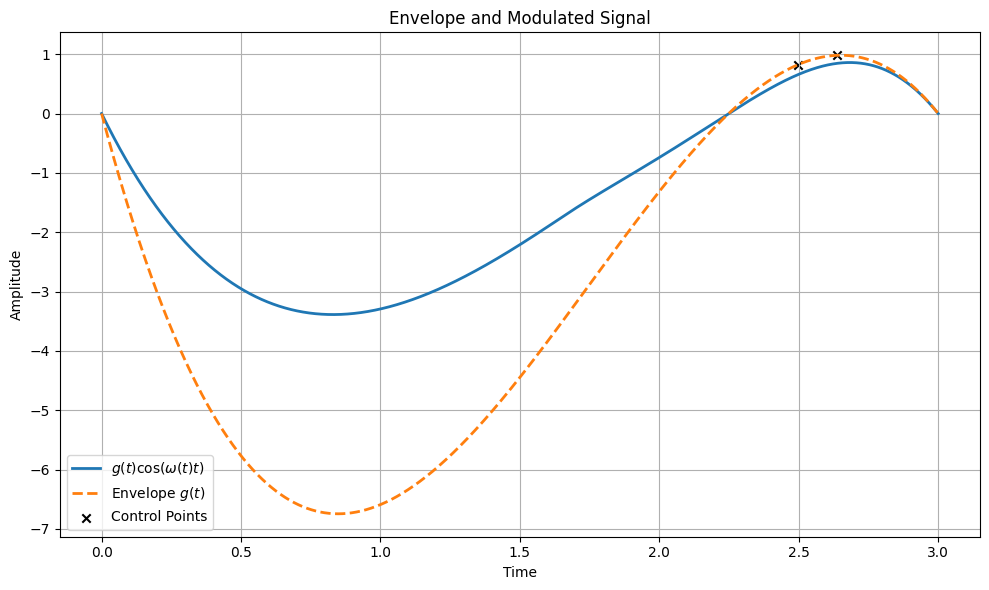

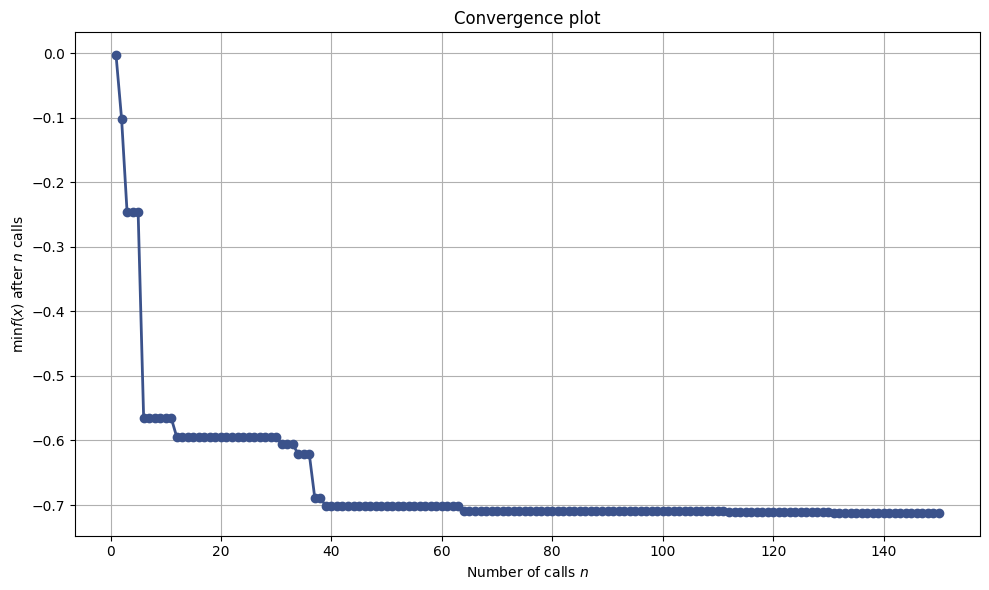

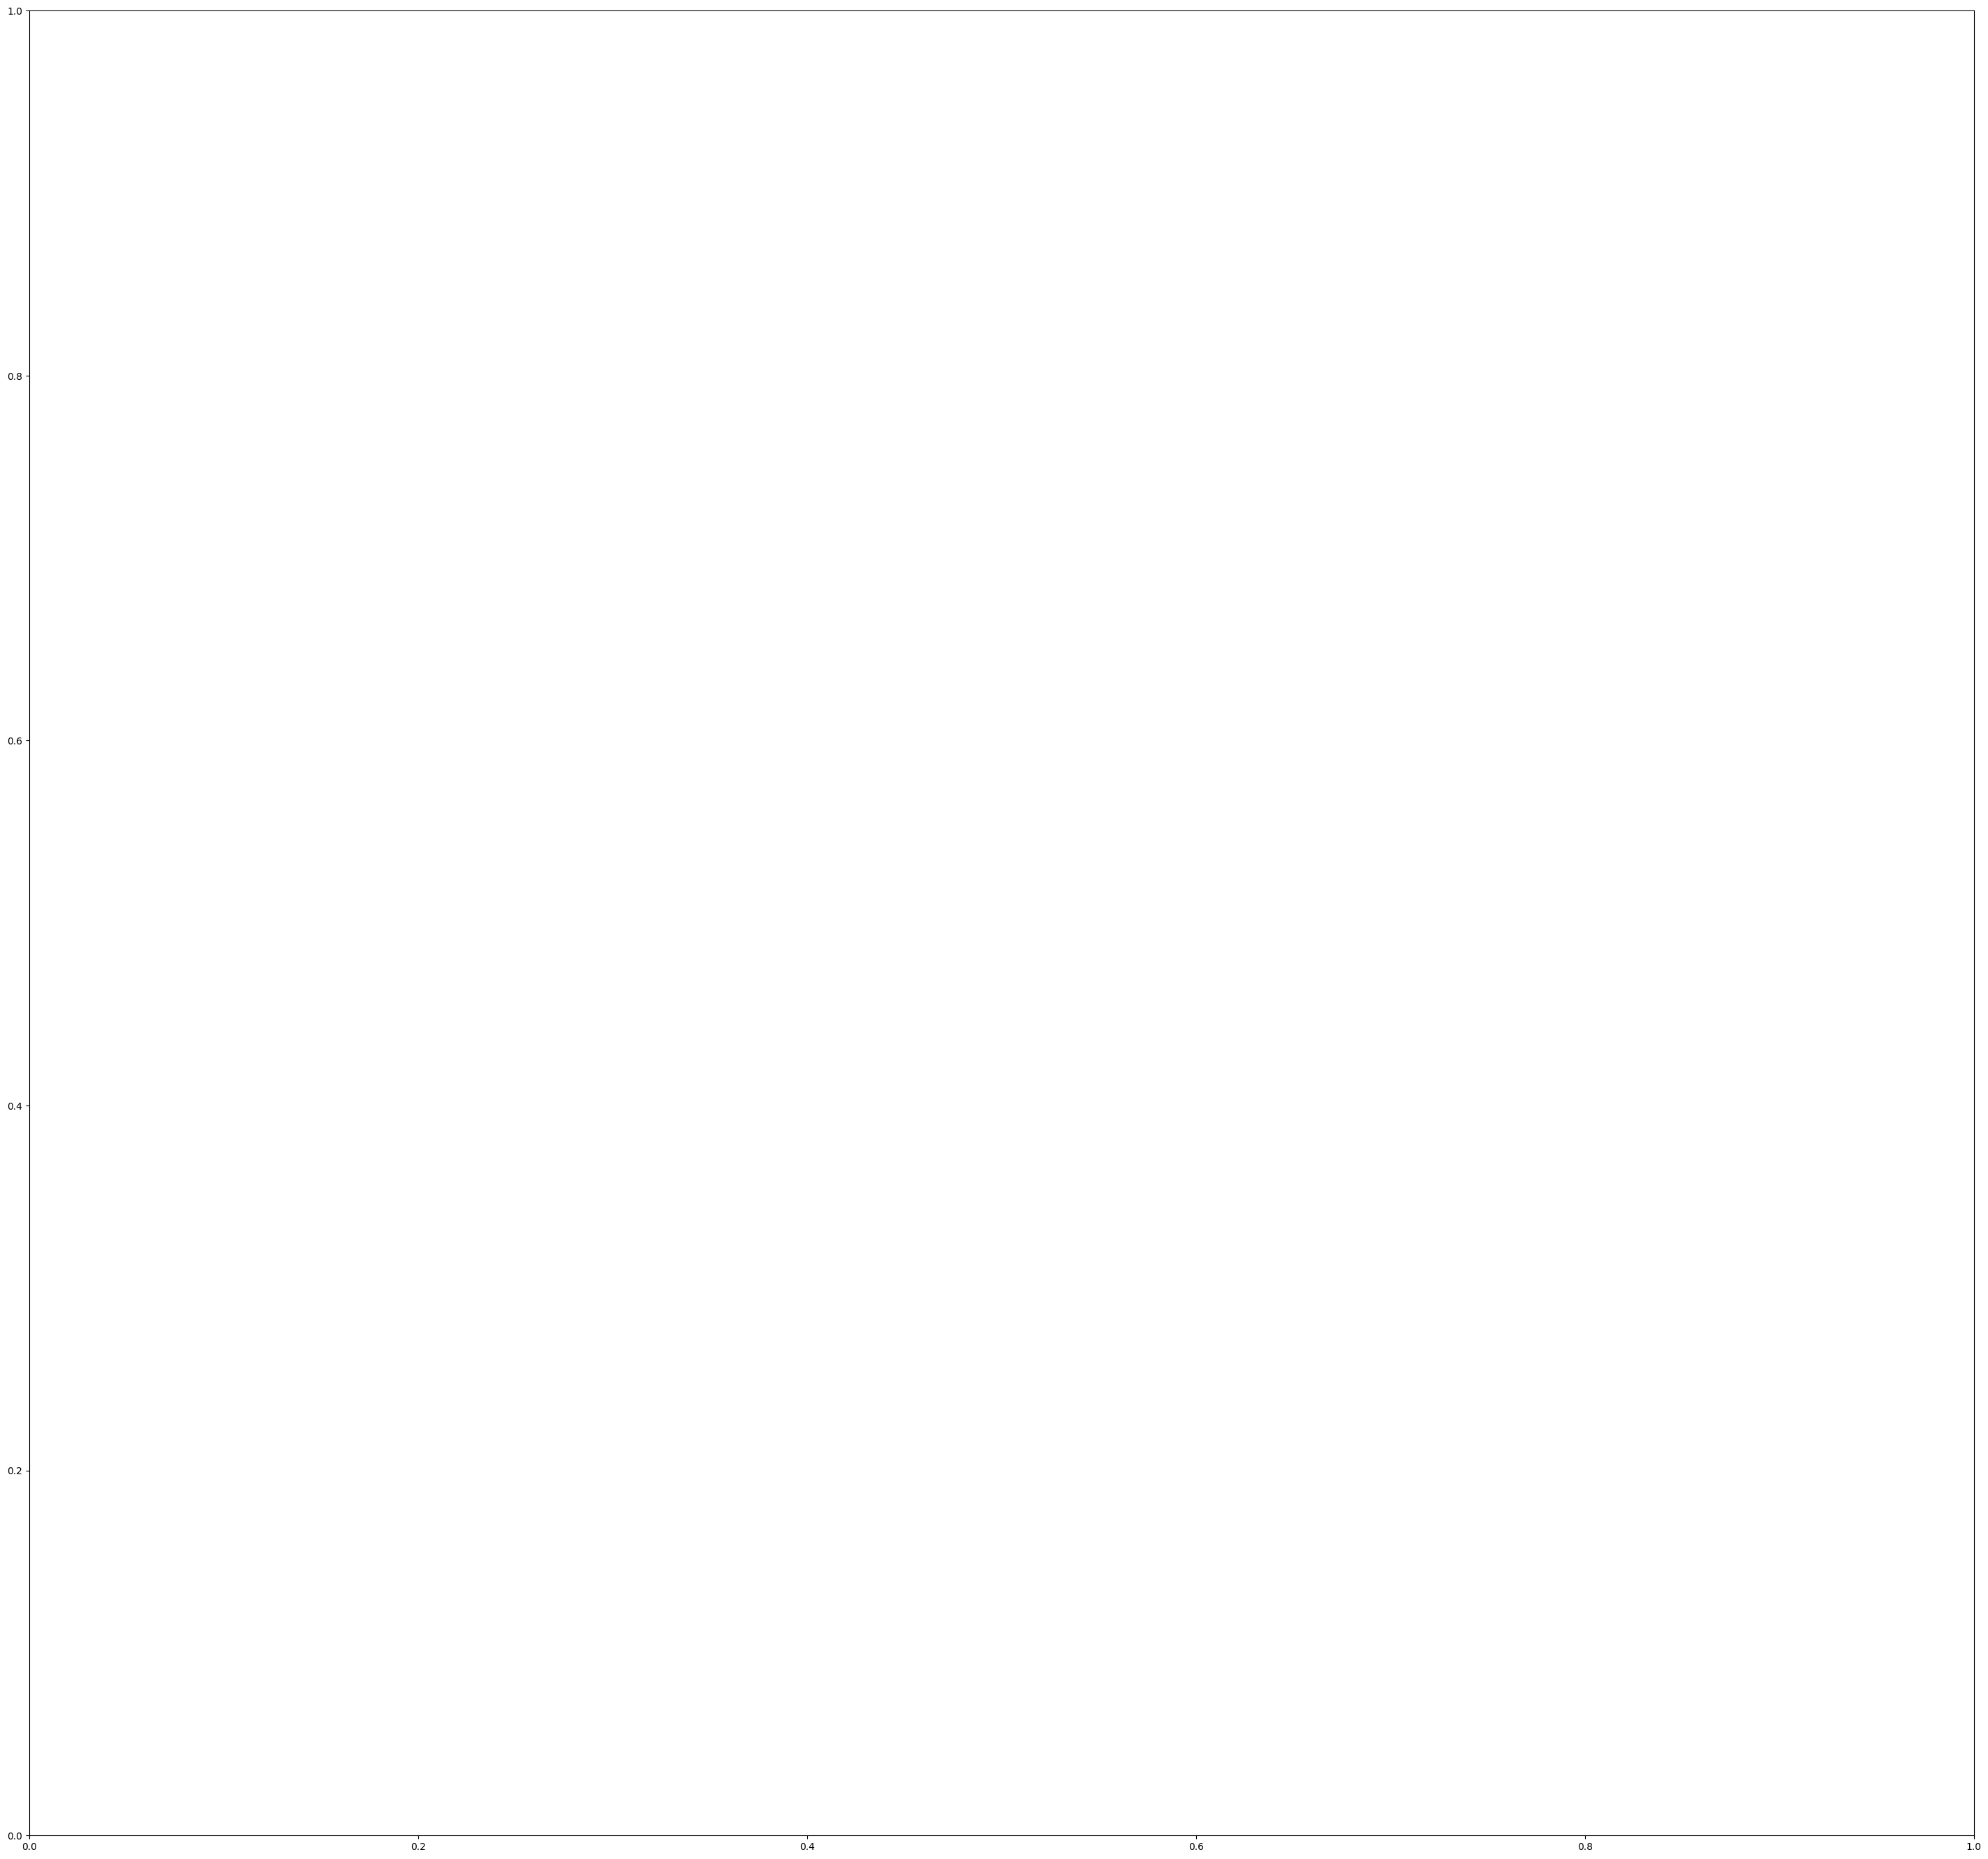

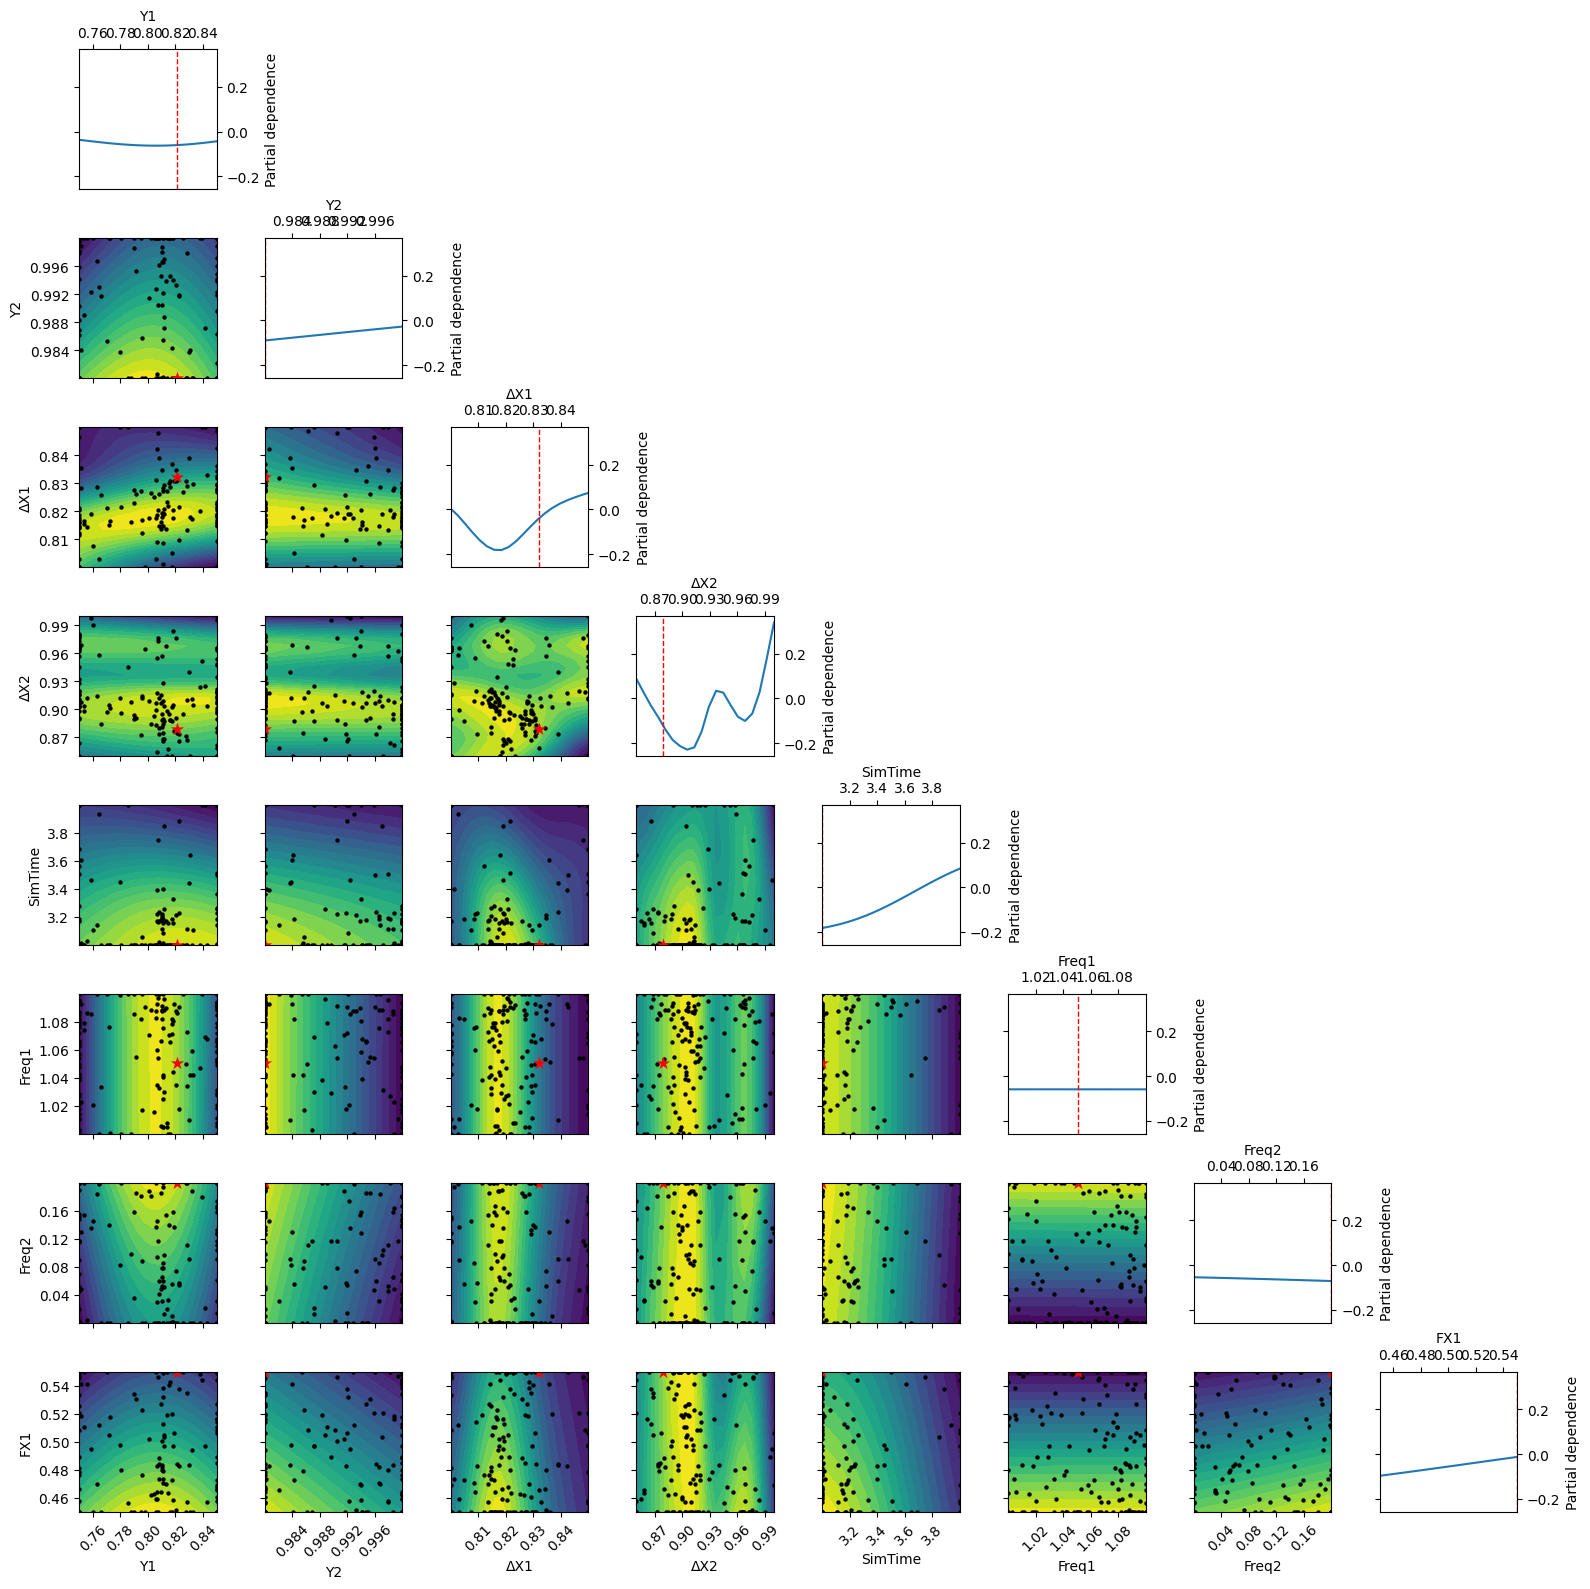

In [6]:

# === Define modulation function ===
def f_t(t, args):
    g_t = float(args['envelope'](t))
    return g_t

# === Time-dependent detunings ===
def delta_c_t(t, args):
    return wc - float(args['frequency'](t))

def delta_a_t(t, args):
    return wa - float(args['frequency'](t))

# === Define search space ===
space = [
    # FIXED (or ultra-narrow) envelope heights
    Real(0.75*g, 0.85*g, name="Y1"),
    Real(0.98*g, g, name="Y2"),

    # Break-points ordered inside the pulse
    Real(0.8, 0.85, name="ΔX1"),
    Real(0.85, 1, name="ΔX2"),

    # Total simulation time
    Real(3/g, 4/g, name="SimTime"),

    # Chirp apex
    Real(wa, 1.1*wa, name="Freq1"),
    Real(0, 0.2*wa, name='Freq2'),

    # Apex location (fraction of τ)
    Real(0.45, 0.55, name="FX1")

]


# === Run optimization and analysis ===
def run_optimization_and_analysis(f_t, space, plot=True, n_calls=50, random_state=42):
    def objective_general(envelope_y1, envelope_y2, delta_ex1, delta_ex2, sim_time,
                          freq1, freq2, fx1):

        tau = wc * sim_time
        envelope_x1 = tau * min(delta_ex1, delta_ex2)
        envelope_x2 = tau * max(delta_ex1, delta_ex2)
        freq_x1 = tau * fx1

        if not (0 < envelope_x1 < envelope_x2 < tau):
            return 1.0
        if not (0 < freq_x1 < tau):
            return 1.0

        envelope_spline = CubicSpline([0, envelope_x1, envelope_x2, tau], [0, envelope_y1, envelope_y2, 0], extrapolate=False)
        frequency_spline = CubicSpline([0, freq_x1, tau], [wa , freq1, freq2])

        args = {'envelope': envelope_spline, 'frequency': frequency_spline, 'sim_time': sim_time}

        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]


        try:
            result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                             options={'nsteps': 1e8, 'atol': 1e-7, 'rtol': 1e-7},
                             args=args)
            final_rho = result.states[-1]
            fidelity_custom = expect(target_state.proj(), final_rho)
            return -fidelity_custom
        except Exception as e:
            print("Simulation error:", e)
            return 1.0

    def objective(x):
        return objective_general(*x)

    res_1 = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y1, Y2, delta_X1, delta_X2, sim_time, freq1, freq2, fx1) = res_1.x
        tau = wc * sim_time
        X1 = tau * min(delta_X1, delta_X2)
        X2 = tau * max(delta_X1, delta_X2)
        freq_x1 = tau * fx1

        tau_arr = np.linspace(0, tau, 5000)
        envelope_spline = CubicSpline([0, X1, X2, tau], [0, Y1, Y2, 0], extrapolate=False)
        frequency_spline = PchipInterpolator([0, freq_x1, tau], [wa, freq1, freq2])
        envelope = envelope_spline(tau_arr)
        omega_t = frequency_spline(tau_arr)

        # === Plot 1: Modulated wave and envelope ===
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, envelope * np.cos(omega_t), label=r'$g(t)\cos(\omega(t)t)$', linewidth=2)
        plt.plot(tau_arr, envelope, label=r'Envelope $g(t)$', linestyle='--', linewidth=2)
        plt.scatter([X1, X2], [Y1, Y2], marker='x', color='black', label='Control Points')
        plt.title('Envelope and Modulated Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 2: Convergence ===
        plt.figure(figsize=(10, 6))
        plot_convergence(res_1)
        plt.tight_layout()

        # === Plot 3: Objective landscape ===
        fig, ax = plt.subplots(figsize=(36, 34))
        ax = plot_objective(res_1, dimensions=[
            'Y1', 'Y2', 'ΔX1', 'ΔX2', 'SimTime',
            'Freq1', 'Freq2','FX1'
        ], n_points=20, levels=20)
        plt.tight_layout()

        # === Plot 4: Population dynamics ===
        args = {'envelope': envelope, 'frequency': omega_t}
        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]
        output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args, store_states = True)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, n_c, label='Cavity Photon Number')
        plt.plot(tau_arr, n_a, label='Atom Excited State')
        plt.xlabel('Time')
        plt.ylabel('Occupation')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # === Plot 5: ω(t) ===
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
        plt.scatter([freq_x1], [freq1], color='black', marker='x', s=80, label='Frequency Control Point')
        plt.title('Time-Dependent Frequency')
        plt.xlabel('Time')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 6: detuning ===
        omega_t = frequency_spline(tau_arr)
        delta_c = wc - omega_t
        delta_a = wa - omega_t

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, delta_c, label=r'$\Delta_c(t) = \omega_c - \omega(t)$', linewidth=2)
        plt.plot(tau_arr, delta_a, label=r'$\Delta_a(t) = \omega_a - \omega(t)$', linewidth=2)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.title('Time-Dependent Detunings')
        plt.xlabel('Time')
        plt.ylabel('Detuning')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # === Plot 7: Cavity Fock State Populations ===
        fock_populations = {n: [] for n in range(n_cavity)}
        for state in output.states:
            for n in range(n_cavity):
                projector = tensor(fock(n_cavity, n).proj(), qeye(2))
                fock_populations[n].append(expect(projector, state))

        plt.figure(figsize=(10, 6))
        for n in range(n_cavity):
            plt.plot(tau_arr, fock_populations[n], label=f'Fock |{n}⟩')
        plt.xlabel("Time")
        plt.ylabel("Population")
        plt.title("Cavity Fock State Populations Over Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

    return res_1

# Now call the function
res_1 = run_optimization_and_analysis(f_t, space)

In [ ]:
param_names = ["Y1", "Y2", "ΔX1", "ΔX2", "SimTime", "Freq1", 'Freq2', "FX1"]
for name, val in zip(param_names, res_1.x):
    print(f"{name} = {val:.6f}")